# Order Lifecycle Analysis: From Submission to Cancellation or Execution

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Track individual NASDAQ limit orders from submission to first termination
event (delete, partial cancel, or replace) and to first execution, and
quantify the resulting cancellation- and execution-rate distributions across
the ITCH sample.

## Learning Objectives

After completing this notebook, you will be able to:
- Reconstruct order lifecycles from add (`A`/`F`), delete (`D`), partial cancel
  (`X`), replace (`U`), and execute (`E`/`C`) ITCH messages.
- Compute cancellation and execution rates (cancellation dominates in modern
  equity markets at ~96%, with execution near 4%), along with the time
  distributions that characterize HFT-driven order flow.
- Separate "still resting at end-of-sample" orders from "executed-then-deleted"
  orders so cancellation and execution are not double-counted.

## Book reference

Section §3.3, *From Raw Messages to the Limit Order Book* — empirical-findings
subsection on cancellation rates and time-to-cancel/execute distributions.

## Prerequisites

- Parsed ITCH message parquets at `data/equities/market/microstructure/nasdaq_itch/messages/`
  (output of `01_itch_parser` or the Rust parser).
- Symbol-level analysis defaults to AAPL; market-wide aggregates use all
  available days.

---

## Why Order Lifecycle Matters

Understanding order lifecycle is crucial for:

| Application | Insight |
|-------------|---------|
| **Execution algorithms** | Estimate fill probability at different price levels |
| **Market making** | Calibrate quote update frequency |
| **Signal development** | Detect informed trading via order persistence |
| **Transaction costs** | Model slippage and market impact |

The ~96% cancellation rate has profound implications:
- Most "visible" liquidity is **phantom** - it disappears before you can trade against it
- Market makers continuously update quotes based on new information
- Aggressive strategies must account for rapidly changing order book state

## Setup

In [1]:
"""Order Lifecycle Analysis — track limit orders from submission to cancellation or execution."""

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pyarrow.dataset as ds
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from data import load_nasdaq_itch
from utils.paths import get_output_dir

sns.set_style("whitegrid")

In [2]:
# Production defaults — Papermill injects overrides for CI

In [3]:
# Configuration - Unified output directory structure
# All ITCH-related outputs under a single chapter directory
NASDAQ_ITCH_OUTPUT = get_output_dir(3, "nasdaq_itch")

# Input: Parsed messages from canonical loader path
MESSAGE_DIR = load_nasdaq_itch(get_base_path=True)

# Output: This notebook's analysis outputs
OUTPUT_DIR = NASDAQ_ITCH_OUTPUT / "order_lifecycle"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Configuration for analysis
# SYMBOL: Which stock to analyze (required - we filter to single stock for memory efficiency)
SYMBOL = "AAPL"

# MAX_ORDERS: Optional row limit for testing (None = no limit after symbol filter)
MAX_ORDERS = None

print(f"Input directory (messages): {MESSAGE_DIR}")
print(f"Output directory (analysis): {OUTPUT_DIR}")
print(f"Analyzing symbol: {SYMBOL}")

Input directory (messages): data/equities/market/microstructure/nasdaq_itch/messages
Output directory (analysis): 03_market_microstructure/output/nasdaq_itch/order_lifecycle
Analyzing symbol: AAPL


In [4]:
if not MESSAGE_DIR.exists():
    print(f"\nWARNING: Message directory not found: {MESSAGE_DIR}")
    print("   Run 01_itch_parser first to parse ITCH data.")
    available = []
else:
    available = sorted([d.name for d in MESSAGE_DIR.iterdir() if d.is_dir()])
    print(f"\nAvailable message types: {available}")

# Check if we have message data to analyze
HAS_MESSAGE_DATA = len(available) > 0

if not HAS_MESSAGE_DATA:
    raise RuntimeError(
        "No parsed ITCH message data found.\n"
        "This notebook requires output from 01_itch_parser (full parse ~60min).\n"
        f"Expected directory: {MESSAGE_DIR}"
    )

# Get stock_locate for our symbol (needed to filter D/E/X/U messages which lack 'stock' column)
r_dir = MESSAGE_DIR / "R"
if r_dir.exists():
    stock_directory = pl.scan_parquet(r_dir).collect()
    symbol_match = stock_directory.filter(pl.col("stock") == SYMBOL)
    if len(symbol_match) > 0:
        STOCK_LOCATE = symbol_match["stock_locate"][0]
        print(f"\nAnalyzing symbol: {SYMBOL} (stock_locate={STOCK_LOCATE})")
    else:
        raise ValueError(f"Symbol {SYMBOL} not found in R messages")
else:
    raise RuntimeError("R (Stock Directory) messages not found")


Available message types: ['A', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'P', 'Q', 'R', 'S', 'U', 'V', 'X', 'Y', 'enriched']

Analyzing symbol: AAPL (stock_locate=13)


## Helper Functions

Functions to load different message types from Parquet files.

In [5]:
def _load_filtered_df(msg_dir, symbol, stock_locate, columns, limit):
    """Scan parquet, apply symbol/stock_locate filter, select columns, and collect."""
    lf = pl.scan_parquet(msg_dir / "*.parquet")
    schema = lf.collect_schema()

    # CRITICAL: Filter by symbol/stock_locate BEFORE collecting (predicate pushdown)
    if "stock" in schema and symbol:
        lf = lf.filter(pl.col("stock") == symbol)
    elif "stock_locate" in schema and stock_locate is not None:
        lf = lf.filter(pl.col("stock_locate") == stock_locate)

    if columns:
        # Only select columns that exist
        available_cols = schema.names()
        valid_cols = [c for c in columns if c in available_cols]
        if valid_cols:
            lf = lf.select(valid_cols)

    # Apply row limit AFTER symbol filter
    if limit:
        lf = lf.head(limit)

    return lf.collect()

### Post-Process Message DataFrame
Validate timestamp dtypes and normalize ITCH price4 format after loading.

In [6]:
def _postprocess_message_df(df, msg_type):
    """Validate timestamp dtypes and normalize ITCH price4 format."""
    # Validate timestamp dtype - critical for correct timing calculations
    if "timestamp" in df.columns:
        ts_dtype = df.schema["timestamp"]
        if not isinstance(ts_dtype, pl.Datetime):
            # If timestamp is integer (nanoseconds since midnight), convert to duration
            if ts_dtype in (pl.Int64, pl.UInt64, pl.Int32, pl.UInt32):
                df = df.with_columns(
                    pl.duration(nanoseconds=pl.col("timestamp")).alias("timestamp")
                )
                print(
                    f"  Warning: {msg_type} timestamps converted from integer (assumed nanoseconds)"
                )

    # Normalize prices from ITCH price4 format (divide by 10000)
    # ITCH stores prices as integers with 4 implied decimal places
    price_cols = ["price", "execution_price"]
    for col in price_cols:
        if col in df.columns:
            # Heuristic: if median price > 10000, assume not yet normalized
            median_price = df.select(pl.col(col).median()).item()
            if median_price is not None and median_price > 10000:
                df = df.with_columns((pl.col(col) / 10000).alias(col))

    return df

### Load Message Type
Load a specific ITCH message type with optional symbol filtering and column selection.

In [7]:
def load_message_type(
    msg_type: str,
    columns: list | None = None,
    limit: int | None = None,
    symbol: str | None = None,
    stock_locate: int | None = None,
) -> pl.DataFrame:
    """Load a specific message type from Parquet files using Polars.

    Args:
        msg_type: Message type code (A, D, E, etc.)
        columns: Optional list of columns to select
        limit: Optional row limit (useful with large files)
        symbol: Filter by stock symbol (for A, F, P, R messages with 'stock' column)
        stock_locate: Filter by stock_locate ID (for D, E, X, C, U messages)

    Returns:
        DataFrame with requested columns. Timestamps are validated to be Datetime type.
        Empty DataFrame if message type directory doesn't exist.

    Note:
        ITCH message types have different columns:
        - A, F, P, R: Have 'stock' column - filter by symbol
        - D, E, X, C, U: Only have 'stock_locate' - filter by stock_locate ID
        Always filter by symbol/stock_locate to avoid loading all market data.
    """
    msg_dir = MESSAGE_DIR / msg_type
    if not msg_dir.exists():
        return pl.DataFrame()

    # Use MAX_ORDERS as default limit if not specified
    if limit is None:
        limit = MAX_ORDERS

    # Use global symbol/stock_locate if not specified
    if symbol is None:
        symbol = SYMBOL
    if stock_locate is None:
        stock_locate = STOCK_LOCATE

    try:
        df = _load_filtered_df(msg_dir, symbol, stock_locate, columns, limit)
        return _postprocess_message_df(df, msg_type)
    except Exception as e:
        print(f"Error loading {msg_type}: {e}")
        return pl.DataFrame()

### Count Messages by Type

Aggregate message counts across all Parquet partitions.

In [8]:
def count_messages() -> dict[str, int]:
    """Count messages by type."""
    counts = {}
    for sub in MESSAGE_DIR.iterdir():
        if sub.is_dir():
            try:
                dset = ds.dataset(sub.as_posix(), format="parquet")
                counts[sub.name] = sum(f.metadata.num_rows for f in dset.get_fragments())
            except Exception:
                pass
    return counts

## 1. Trading Day Summary

First, let's see the distribution of message types to understand market activity.

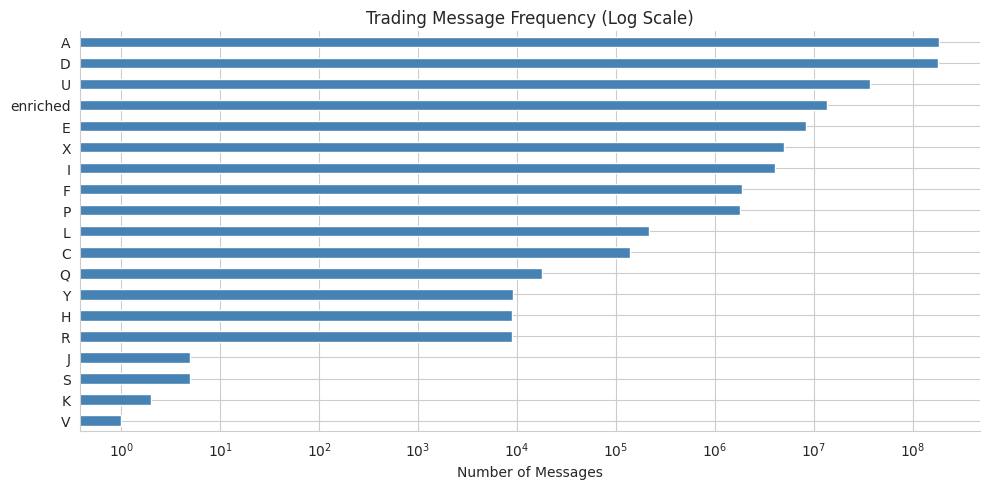

Message counts:
  A:  184,735,355
  D:  180,285,101
  U:   36,777,372
  enriched:   13,546,061
  E:    8,415,610
  X:    4,990,972
  I:    4,025,192
  F:    1,875,350
  P:    1,779,727
  L:      216,802
  C:      139,474
  Q:       17,835
  Y:        9,068
  H:        8,921
  R:        8,916
  S:            5
  J:            5
  K:            2
  V:            1


In [9]:
if HAS_MESSAGE_DATA:
    message_counts = count_messages()
    # Sort by count descending
    message_counts = dict(sorted(message_counts.items(), key=lambda x: -x[1]))

    # Convert to pandas for matplotlib (simple dict plotting)
    import pandas as pd

    fig, ax = plt.subplots(figsize=(10, 5))
    pd.Series(message_counts).sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_xscale("log")
    ax.set_title("Trading Message Frequency (Log Scale)")
    ax.set_xlabel("Number of Messages")
    sns.despine()
    plt.tight_layout()
    plt.show()

    print("Message counts:")
    for msg_type, count in message_counts.items():
        print(f"  {msg_type}: {count:>12,}")

**Key Observations**:
- Add orders (A, F) and cancellations (D, X) dominate the message flow
- Actual executions (E, C) are much less frequent
- This asymmetry is the first hint of high cancellation rates

## 2. Order Characteristics

Load limit order submissions (Add Order messages) to understand order characteristics.

In [10]:
# Load and combine Add Order messages
if HAS_MESSAGE_DATA:
    # Load Add Order messages (A = anonymous, F = with attribution)
    add_a = load_message_type("A")
    add_f = load_message_type("F")

    # Combine both types (use diagonal_relaxed for schema differences)
    if len(add_a) > 0 and len(add_f) > 0:
        limit_orders = pl.concat([add_a, add_f], how="diagonal_relaxed")
    elif len(add_a) > 0:
        limit_orders = add_a
    elif len(add_f) > 0:
        limit_orders = add_f
    else:
        limit_orders = pl.DataFrame()

    if len(limit_orders) > 0:
        # Standardize columns using rename
        rename_map = {
            "order_reference_number": "order",
            "buy_sell_indicator": "side",
            "timestamp": "submitted",
            "stock": "ticker",
        }
        for old, new in rename_map.items():
            if old in limit_orders.columns:
                limit_orders = limit_orders.rename({old: new})

        # Convert side to numeric using Polars when/then
        # Cast to string first to handle bytes/string mix
        if "side" in limit_orders.columns:
            limit_orders = limit_orders.with_columns(pl.col("side").cast(pl.Utf8).alias("side_str"))
            limit_orders = limit_orders.with_columns(
                pl.when(pl.col("side_str") == "B")
                .then(1)
                .when(pl.col("side_str") == "S")
                .then(-1)
                .otherwise(0)
                .alias("side_num")
            )

        print(f"Loaded {len(limit_orders):,} limit orders")
        print(limit_orders.schema)

Loaded 907,157 limit orders
Schema({'stock_locate': UInt16, 'tracking_number': UInt16, 'submitted': Datetime(time_unit='ns', time_zone=None), 'order': UInt64, 'side': String, 'shares': UInt32, 'ticker': String, 'price': Float64, 'attribution': String, 'side_str': String, 'side_num': Int32})


In [11]:
# Price sanity check
if HAS_MESSAGE_DATA and len(limit_orders) > 0 and "price" in limit_orders.columns:
    price_stats = limit_orders.select(
        [
            pl.col("price").min().alias("min"),
            pl.col("price").median().alias("median"),
            pl.col("price").max().alias("max"),
        ]
    ).row(0, named=True)
    print("Price sanity check (should be plausible dollar values):")
    print(
        f"  Min: ${price_stats['min']:.2f}, Median: ${price_stats['median']:.2f}, Max: ${price_stats['max']:.2f}"
    )

    # Warning if prices look scaled (ITCH often uses 1/10000 scaling)
    if price_stats["median"] > 100000:
        print("  WARNING: Prices appear to be scaled integers, not dollars!")
        print("  Check that the ITCH parser normalizes prices correctly.")

Price sanity check (should be plausible dollar values):
  Min: $0.00, Median: $321.31, Max: $199999.99


### 2.1 Order Size Distribution

Top 10 Most Common Order Sizes:
       100 shares (side=-1): 37.56%
       100 shares (side= 1): 35.45%
       200 shares (side=-1): 2.33%
       200 shares (side= 1): 2.19%
        30 shares (side=-1): 1.12%
        30 shares (side= 1): 1.00%
         1 shares (side=-1): 0.81%
        15 shares (side= 1): 0.80%
         1 shares (side= 1): 0.75%
        15 shares (side=-1): 0.73%


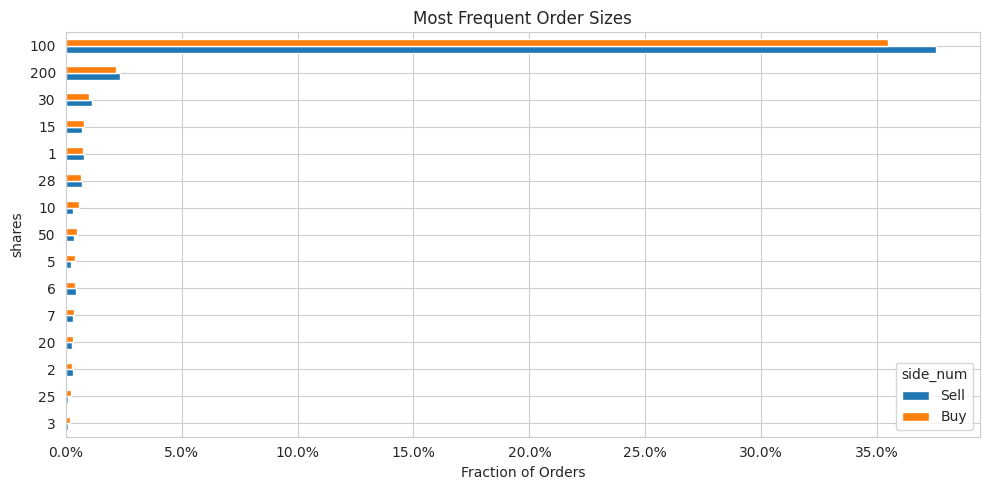

In [12]:
if HAS_MESSAGE_DATA and len(limit_orders) > 0 and "shares" in limit_orders.columns:
    # Top order sizes
    order_sizes = (
        limit_orders.group_by(["shares", "side_num"])
        .agg(pl.len().alias("count"))
        .with_columns((pl.col("count") / pl.col("count").sum()).alias("proportion"))
        .sort("count", descending=True)
    )

    print("Top 10 Most Common Order Sizes:")
    top_10 = order_sizes.head(10)
    for row in top_10.iter_rows(named=True):
        print(
            f"  {row['shares']:>8,.0f} shares (side={row['side_num']:>2}): {row['proportion']:.2%}"
        )

    # Plot distribution - convert to pandas for pivot
    order_sizes_pd = order_sizes.to_pandas()
    size_by_side = order_sizes_pd.pivot_table(
        index="shares", columns="side_num", values="proportion", aggfunc="sum"
    ).rename(columns={1: "Buy", -1: "Sell"})

    fig, ax = plt.subplots(figsize=(10, 5))
    size_by_side.nlargest(15, "Buy").sort_values("Buy").plot.barh(ax=ax)
    ax.set_title("Most Frequent Order Sizes")
    ax.set_xlabel("Fraction of Orders")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
    plt.tight_layout()
    plt.show()

**Observations**:
- Round lots (multiples of 100) dominate order sizes
- 100-share orders are often the most common (retail and algorithmic)
- Buy and sell distributions are typically symmetric

### 2.2 Order Value Distribution

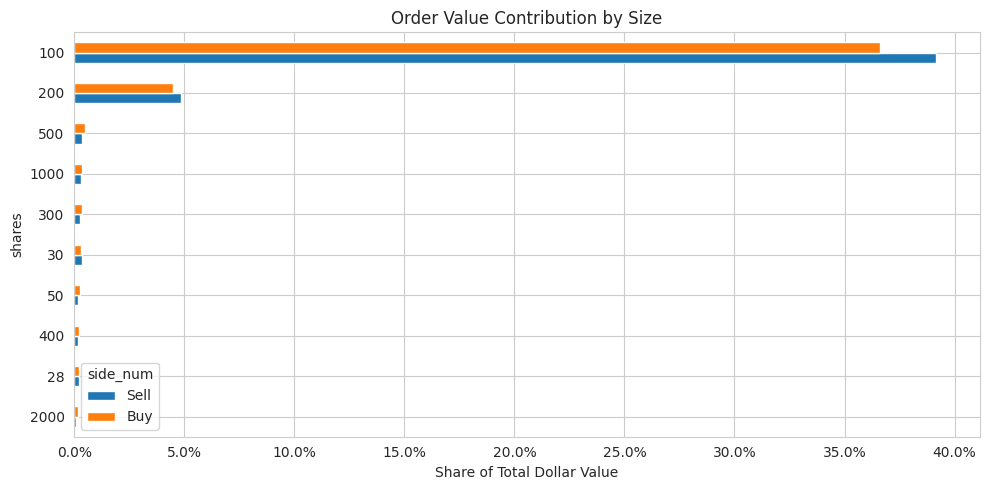

In [13]:
if (
    HAS_MESSAGE_DATA
    and len(limit_orders) > 0
    and "price" in limit_orders.columns
    and "shares" in limit_orders.columns
):
    # Calculate dollar value per order
    limit_orders = limit_orders.with_columns(
        (pl.col("shares").cast(pl.Float64) * pl.col("price").cast(pl.Float64)).alias("value")
    )

    # Value contribution by order size
    value_by_size = limit_orders.group_by(["shares", "side_num"]).agg(
        pl.col("value").sum().alias("total_value")
    )

    total_value = value_by_size.select(pl.col("total_value").sum()).item()
    value_by_size = value_by_size.with_columns(
        (pl.col("total_value") / total_value).alias("value_share")
    )

    # Convert to pandas for pivot plot
    value_by_size_pd = value_by_size.to_pandas()
    value_pivot = value_by_size_pd.pivot_table(
        index="shares", columns="side_num", values="value_share", aggfunc="sum"
    ).rename(columns={1: "Buy", -1: "Sell"})

    fig, ax = plt.subplots(figsize=(10, 5))
    value_pivot.nlargest(10, "Buy").sort_values("Buy").plot.barh(ax=ax)
    ax.set_title("Order Value Contribution by Size")
    ax.set_xlabel("Share of Total Dollar Value")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
    plt.tight_layout()
    plt.show()

## 3. Cancellations

Modern markets feature extremely high cancellation rates. Let's quantify this.

### Methodology Note

ITCH has multiple termination message types:
- **D (Delete)**: Full order cancellation - liquidity withdrawn
- **X (Cancel)**: Partial cancellation - reduces order size
- **U (Replace)**: Cancels original, creates new order - quote update

For this analysis:
- We track **time to first termination event** per order (not all events)
- Replace (U) terminates the original order but creates a replacement
- Orders can have multiple events (e.g., partial cancel then delete)
- We use **first event timestamp** for timing statistics

In [14]:
# Load termination messages (Delete, Cancel, Replace)
orders_with_cancel = None
orders_with_exec = None
cancelled_orders_df = None
executed_orders_df = None
termination_by_type = None

if HAS_MESSAGE_DATA and len(limit_orders) > 0:
    delete_msgs = load_message_type("D", columns=["order_reference_number", "timestamp"])
    cancel_msgs = load_message_type("X", columns=["order_reference_number", "timestamp"])
    replace_msgs = load_message_type("U", columns=["original_order_reference_number", "timestamp"])

    # Normalize each termination type
    termination_events = []

    if len(delete_msgs) > 0:
        delete_msgs = delete_msgs.rename(
            {"order_reference_number": "order", "timestamp": "terminated"}
        ).with_columns(pl.lit("delete").alias("termination_type"))
        termination_events.append(delete_msgs.select(["order", "terminated", "termination_type"]))

    if len(cancel_msgs) > 0:
        cancel_msgs = cancel_msgs.rename(
            {"order_reference_number": "order", "timestamp": "terminated"}
        ).with_columns(pl.lit("cancel").alias("termination_type"))
        termination_events.append(cancel_msgs.select(["order", "terminated", "termination_type"]))

    if len(replace_msgs) > 0:
        replace_msgs = replace_msgs.rename(
            {"original_order_reference_number": "order", "timestamp": "terminated"}
        ).with_columns(pl.lit("replace").alias("termination_type"))
        termination_events.append(replace_msgs.select(["order", "terminated", "termination_type"]))

In [15]:
# Deduplicate to first termination event per order and merge with limit orders
if HAS_MESSAGE_DATA and len(limit_orders) > 0 and termination_events:
    all_terminations = pl.concat(termination_events)
    print(f"Total termination events: {len(all_terminations):,}")

    # CRITICAL: Deduplicate to FIRST termination event per order
    # This prevents orders with multiple events from biasing statistics
    first_termination = (
        all_terminations.sort("terminated")
        .group_by("order")
        .agg(
            [
                pl.col("terminated").first().alias("cancelled"),
                pl.col("termination_type").first().alias("termination_type"),
            ]
        )
    )

    print(f"Unique orders with termination: {len(first_termination):,}")

    # Track termination breakdown
    termination_by_type = (
        first_termination.group_by("termination_type")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
    )
    print("\nTermination breakdown (first event per order):")
    for row in termination_by_type.iter_rows(named=True):
        print(f"  {row['termination_type']:>10}: {row['count']:>12,}")

    # Merge with limit orders to get full lifecycle
    orders_with_cancel = limit_orders.join(first_termination, on="order", how="left")
    print(f"\nOrders with termination data: {len(orders_with_cancel):,}")

Total termination events: 1,030,800


Unique orders with termination: 1,020,834

Termination breakdown (first event per order):
      delete:      859,436
     replace:      151,325
      cancel:       10,073

Orders with termination data: 907,157


### 3.1 Cancellation Rate

ORDER TERMINATION ANALYSIS
Total unique orders:          907,157
Orders terminated:            870,273
  (delete/cancel/replace)
Still live or unknown:         36,884
Termination rate:               95.9%


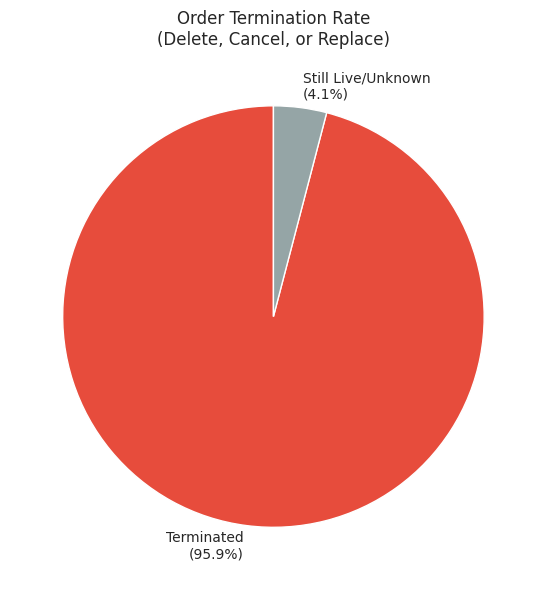


Note: 'Terminated' includes Delete, Cancel, and Replace events.
Replace creates a new order - market makers updating quotes.
'Still Live/Unknown' may include executed orders (see below).


In [16]:
if HAS_MESSAGE_DATA and orders_with_cancel is not None and len(orders_with_cancel) > 0:
    # Calculate termination rate (using first event per order)
    total_orders = orders_with_cancel.select(pl.col("order").n_unique()).item()
    terminated_orders = (
        orders_with_cancel.filter(pl.col("cancelled").is_not_null())
        .select(pl.col("order").n_unique())
        .item()
    )

    termination_rate = terminated_orders / total_orders
    remaining = total_orders - terminated_orders

    print("=" * 50)
    print("ORDER TERMINATION ANALYSIS")
    print("=" * 50)
    print(f"Total unique orders:     {total_orders:>12,}")
    print(f"Orders terminated:       {terminated_orders:>12,}")
    print("  (delete/cancel/replace)")
    print(f"Still live or unknown:   {remaining:>12,}")
    print(f"Termination rate:        {termination_rate:>12.1%}")
    print("=" * 50)

    # Visualize with accurate labels
    # Note: "Still Live/Unknown" includes orders that:
    # - May still be open at end of sample
    # - Were executed (handled separately below)
    # - Had no termination event in our sample
    fig, ax = plt.subplots(figsize=(6, 6))
    sizes = [termination_rate, 1 - termination_rate]
    labels = [
        f"Terminated\n({termination_rate:.1%})",
        f"Still Live/Unknown\n({1 - termination_rate:.1%})",
    ]
    colors = ["#e74c3c", "#95a5a6"]  # Red for terminated, gray for unknown
    ax.pie(sizes, labels=labels, colors=colors, autopct="", startangle=90)
    ax.set_title("Order Termination Rate\n(Delete, Cancel, or Replace)")
    plt.tight_layout()
    plt.show()

    # Also show breakdown by termination type if available
    if termination_by_type is not None and len(termination_by_type) > 0:
        print("\nNote: 'Terminated' includes Delete, Cancel, and Replace events.")
        print("Replace creates a new order - market makers updating quotes.")
        print("'Still Live/Unknown' may include executed orders (see below).")

**Key Finding**: High termination rates in modern markets!

**Important clarification**: The termination rate above includes:
- Delete (D): Full order cancellation
- Cancel (X): Partial size reduction
- Replace (U): Order modification (creates new order)

This is **not** the same as "cancelled without execution" - some orders are
partially executed then terminated. See Section 5 below for the unified
outcome breakdown that separates these cases.

The high termination rate reflects:
- Market makers continuously updating quotes (Replace)
- Algorithmic traders managing inventory risk
- Traders cancelling orders when market conditions change
- Fleeting liquidity that disappears before it can be traded against

### 3.2 Time to First Termination Event

"Termination" here means the first Delete (D), Cancel (X), or Replace (U) event.
Note: This includes orders that may have been partially executed first.

In [17]:
# Compute time-to-cancellation statistics
if HAS_MESSAGE_DATA and orders_with_cancel is not None:
    cancelled_orders_df = orders_with_cancel.filter(pl.col("cancelled").is_not_null())

    if len(cancelled_orders_df) > 0:
        cancelled_orders_df = cancelled_orders_df.with_columns(
            ((pl.col("cancelled") - pl.col("submitted")).dt.total_seconds()).alias("cancel_time")
        )

        cancel_time_stats = cancelled_orders_df.select(
            [
                pl.col("cancel_time").count().alias("count"),
                pl.col("cancel_time").mean().alias("mean"),
                pl.col("cancel_time").std().alias("std"),
                pl.col("cancel_time").min().alias("min"),
                pl.col("cancel_time").quantile(0.1).alias("10%"),
                pl.col("cancel_time").quantile(0.25).alias("25%"),
                pl.col("cancel_time").quantile(0.5).alias("50%"),
                pl.col("cancel_time").quantile(0.75).alias("75%"),
                pl.col("cancel_time").quantile(0.9).alias("90%"),
                pl.col("cancel_time").quantile(0.95).alias("95%"),
                pl.col("cancel_time").quantile(0.99).alias("99%"),
                pl.col("cancel_time").max().alias("max"),
            ]
        ).row(0, named=True)

        print("Time to Cancellation (seconds):")
        print("-" * 40)
        for stat, value in cancel_time_stats.items():
            print(f"{stat:>10}: {value:>12.4f}")

Time to Cancellation (seconds):
----------------------------------------
     count:  870273.0000
      mean:     675.6411
       std:    3830.5668
       min:       0.0000
       10%:       0.0000
       25%:       0.0000
       50%:       0.0000
       75%:       1.0000
       90%:      10.0000
       95%:     143.0000
       99%:   23364.0000
       max:   57589.0000


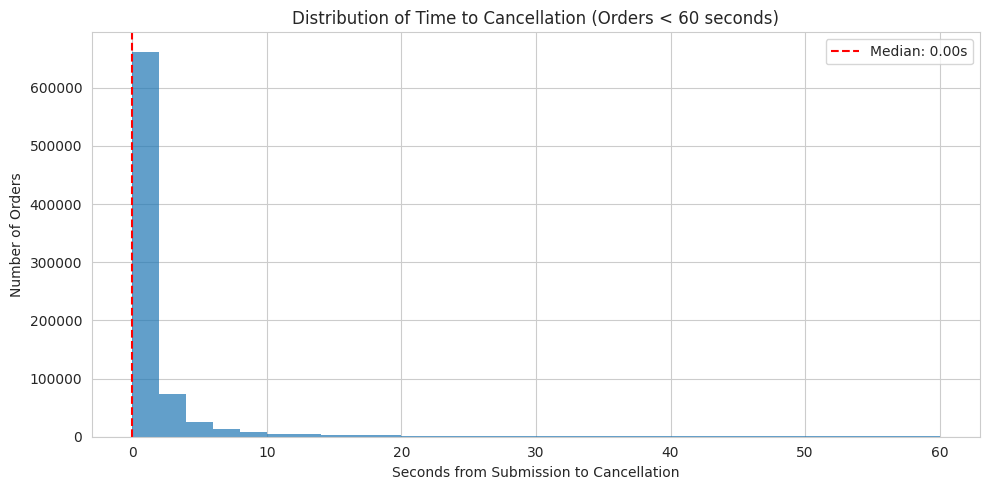


66.6% of cancellations happen within 1 second
89.9% of cancellations happen within 10 seconds


In [18]:
# Cancellation time distribution histogram
if HAS_MESSAGE_DATA and cancelled_orders_df is not None and len(cancelled_orders_df) > 0:
    cancel_times_pd = (
        cancelled_orders_df.filter(pl.col("cancel_time") <= 60).select("cancel_time").to_pandas()
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    _ct = cancel_times_pd["cancel_time"]
    ax.hist(_ct, bins=np.linspace(_ct.min(), _ct.max(), 31), edgecolor="none", alpha=0.7)
    ax.axvline(
        cancel_time_stats["50%"],
        color="red",
        linestyle="--",
        label=f"Median: {cancel_time_stats['50%']:.2f}s",
    )
    ax.set_title("Distribution of Time to Cancellation (Orders < 60 seconds)")
    ax.set_xlabel("Seconds from Submission to Cancellation")
    ax.set_ylabel("Number of Orders")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Key insight
    sub_second = cancelled_orders_df.filter(pl.col("cancel_time") < 1).shape[0] / len(
        cancelled_orders_df
    )
    sub_10_sec = cancelled_orders_df.filter(pl.col("cancel_time") < 10).shape[0] / len(
        cancelled_orders_df
    )
    print(f"\n{sub_second:.1%} of cancellations happen within 1 second")
    print(f"{sub_10_sec:.1%} of cancellations happen within 10 seconds")

**Key Insight**: Most cancellations happen within milliseconds to seconds.
This "fleeting liquidity" is a hallmark of modern electronic markets.

## 4. Executions

Now let's examine the orders that actually trade.

In [19]:
if HAS_MESSAGE_DATA and len(limit_orders) > 0:
    # Load execution messages
    # E = Order Executed
    # C = Order Executed with Price (different from submitted price)
    # Note: An order can have multiple partial executions

    exec_e = load_message_type("E", columns=["order_reference_number", "timestamp"])
    exec_c = load_message_type("C", columns=["order_reference_number", "timestamp"])

    executions = []
    if len(exec_e) > 0:
        exec_e = exec_e.rename({"order_reference_number": "order", "timestamp": "executed"})
        executions.append(exec_e.select(["order", "executed"]))

    if len(exec_c) > 0:
        exec_c = exec_c.rename({"order_reference_number": "order", "timestamp": "executed"})
        executions.append(exec_c.select(["order", "executed"]))

    if executions:
        all_executions = pl.concat(executions)

        print(f"Total execution events: {len(all_executions):,}")

        # CRITICAL FIX: Deduplicate to FIRST execution event per order
        # Orders can have multiple partial fills - we use first fill time
        first_execution = (
            all_executions.sort("executed")
            .group_by("order")
            .agg(pl.col("executed").first().alias("executed"))
        )

        print(f"Unique orders with execution: {len(first_execution):,}")

        # Merge with limit orders using deduplicated executions
        orders_with_exec = limit_orders.join(first_execution, on="order", how="left")

Total execution events: 55,395
Unique orders with execution: 40,846


### 4.1 Execution Rate

In [20]:
if HAS_MESSAGE_DATA and orders_with_exec is not None and len(orders_with_exec) > 0:
    # Calculate execution rate
    total_orders = orders_with_exec.select(pl.col("order").n_unique()).item()
    executed_orders = (
        orders_with_exec.filter(pl.col("executed").is_not_null())
        .select(pl.col("order").n_unique())
        .item()
    )

    exec_rate = executed_orders / total_orders

    print("=" * 50)
    print("EXECUTION RATE ANALYSIS")
    print("=" * 50)
    print(f"Total unique orders:     {total_orders:>12,}")
    print(f"Orders executed:         {executed_orders:>12,}")
    print(f"Execution rate:          {exec_rate:>12.1%}")
    print("=" * 50)

EXECUTION RATE ANALYSIS
Total unique orders:          907,157
Orders executed:               39,987
Execution rate:                  4.4%


### 4.2 Time to Execution

In [21]:
if HAS_MESSAGE_DATA and orders_with_exec is not None:
    # Calculate time from submission to execution
    executed_orders_df = orders_with_exec.filter(pl.col("executed").is_not_null())

    if len(executed_orders_df) > 0:
        executed_orders_df = executed_orders_df.with_columns(
            ((pl.col("executed") - pl.col("submitted")).dt.total_seconds()).alias("exec_time")
        )

        # Summary statistics
        exec_time_stats = executed_orders_df.select(
            [
                pl.col("exec_time").count().alias("count"),
                pl.col("exec_time").mean().alias("mean"),
                pl.col("exec_time").std().alias("std"),
                pl.col("exec_time").min().alias("min"),
                pl.col("exec_time").quantile(0.1).alias("10%"),
                pl.col("exec_time").quantile(0.25).alias("25%"),
                pl.col("exec_time").quantile(0.5).alias("50%"),
                pl.col("exec_time").quantile(0.75).alias("75%"),
                pl.col("exec_time").quantile(0.9).alias("90%"),
                pl.col("exec_time").quantile(0.95).alias("95%"),
                pl.col("exec_time").quantile(0.99).alias("99%"),
                pl.col("exec_time").max().alias("max"),
            ]
        ).row(0, named=True)

        print("Time to Execution (seconds):")
        print("-" * 40)
        for stat, value in exec_time_stats.items():
            print(f"{stat:>10}: {value:>12.4f}")

Time to Execution (seconds):
----------------------------------------
     count:   39987.0000
      mean:     325.0770
       std:    1584.3669
       min:       0.0000
       10%:       0.0000
       25%:       0.0000
       50%:       1.0000
       75%:      10.0000
       90%:     247.0000
       95%:    1556.0000
       99%:    5984.0000
       max:   43252.0000


## 5. Unified Order Outcome Classification

**Important**: Execution and termination are not mutually exclusive!
An order can be partially executed and then cancelled.
Here we build a unified view of order outcomes.

In [22]:
unified = None

if (
    HAS_MESSAGE_DATA
    and orders_with_cancel is not None
    and orders_with_exec is not None
    and len(limit_orders) > 0
):
    # Build unified outcomes table
    # Start with all orders
    unified = limit_orders.select(["order"]).unique()

    # Add execution flag
    executed_orders_set = (
        orders_with_exec.filter(pl.col("executed").is_not_null()).select("order").unique()
    )
    unified = unified.with_columns(
        pl.col("order").is_in(executed_orders_set["order"]).alias("has_execution")
    )

    # Add termination flag
    terminated_orders_set = (
        orders_with_cancel.filter(pl.col("cancelled").is_not_null()).select("order").unique()
    )
    unified = unified.with_columns(
        pl.col("order").is_in(terminated_orders_set["order"]).alias("has_termination")
    )

    # Create mutually exclusive outcome categories
    unified = unified.with_columns(
        pl.when(pl.col("has_execution") & pl.col("has_termination"))
        .then(pl.lit("Executed then Terminated"))
        .when(pl.col("has_execution") & ~pl.col("has_termination"))
        .then(pl.lit("Executed Only"))
        .when(~pl.col("has_execution") & pl.col("has_termination"))
        .then(pl.lit("Terminated Only"))
        .otherwise(pl.lit("Still Live/Unknown"))
        .alias("outcome")
    )

In [23]:
if unified is not None:
    # Compute outcome statistics
    outcome_stats = (
        unified.group_by("outcome")
        .agg(pl.len().alias("count"))
        .with_columns((pl.col("count") / pl.col("count").sum()).alias("rate"))
        .sort("count", descending=True)
    )

    print("=" * 60)
    print("UNIFIED ORDER OUTCOME CLASSIFICATION")
    print("=" * 60)
    total_unified = unified.shape[0]
    print(f"Total unique orders: {total_unified:,}")
    print("-" * 60)
    for row in outcome_stats.iter_rows(named=True):
        print(f"  {row['outcome']:<25}: {row['count']:>10,} ({row['rate']:>6.1%})")
    print("=" * 60)
    print("\nNote: 'Executed then Terminated' means partial fill then cancel/delete.")
    print("This reconciles execution and termination rates into exclusive categories.")

UNIFIED ORDER OUTCOME CLASSIFICATION
Total unique orders: 907,157
------------------------------------------------------------
  Terminated Only          :    867,170 ( 95.6%)
  Executed Only            :     36,884 (  4.1%)
  Executed then Terminated :      3,103 (  0.3%)

Note: 'Executed then Terminated' means partial fill then cancel/delete.
This reconciles execution and termination rates into exclusive categories.


## 6. Comparing Termination vs. Execution Timing

In [24]:
if (
    HAS_MESSAGE_DATA
    and cancelled_orders_df is not None
    and len(cancelled_orders_df) > 0
    and executed_orders_df is not None
    and len(executed_orders_df) > 0
):
    # Create comparison table
    print("Time Comparison: Cancellations vs. Executions (seconds)")
    print("=" * 60)
    print(f"{'Statistic':<15} {'Cancellations':>15} {'Executions':>15}")
    print("-" * 60)
    for stat in ["10%", "25%", "50%", "75%", "90%"]:
        cancel_val = cancel_time_stats.get(stat, 0)
        exec_val = exec_time_stats.get(stat, 0)
        print(f"{stat:<15} {cancel_val:>15.4f} {exec_val:>15.4f}")

Time Comparison: Cancellations vs. Executions (seconds)
Statistic         Cancellations      Executions
------------------------------------------------------------
10%                      0.0000          0.0000
25%                      0.0000          0.0000
50%                      0.0000          1.0000
75%                      1.0000         10.0000
90%                     10.0000        247.0000


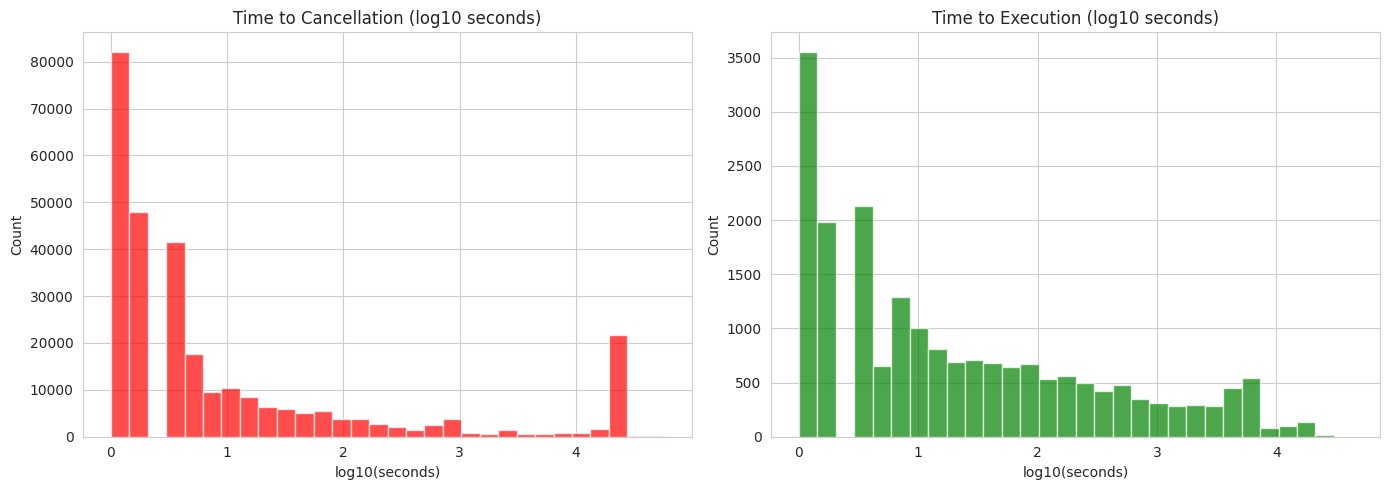

In [25]:
if (
    HAS_MESSAGE_DATA
    and cancelled_orders_df is not None
    and len(cancelled_orders_df) > 0
    and executed_orders_df is not None
    and len(executed_orders_df) > 0
):
    # Dual histogram
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Cancellation times (log scale)
    ax1 = axes[0]
    cancel_times = (
        cancelled_orders_df.filter(pl.col("cancel_time") > 0)
        .select("cancel_time")
        .to_numpy()
        .flatten()
    )
    _lc = np.log10(cancel_times + 0.001)
    ax1.hist(_lc, bins=np.linspace(_lc.min(), _lc.max(), 31), alpha=0.7, color="red")
    ax1.set_title("Time to Cancellation (log10 seconds)")
    ax1.set_xlabel("log10(seconds)")
    ax1.set_ylabel("Count")

    # Execution times (log scale)
    ax2 = axes[1]
    exec_times = (
        executed_orders_df.filter(pl.col("exec_time") > 0).select("exec_time").to_numpy().flatten()
    )
    _le = np.log10(exec_times + 0.001)
    ax2.hist(_le, bins=np.linspace(_le.min(), _le.max(), 31), alpha=0.7, color="green")
    ax2.set_title("Time to Execution (log10 seconds)")
    ax2.set_xlabel("log10(seconds)")
    ax2.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

## 7. Top Traded Symbols

Which symbols have the highest execution activity?

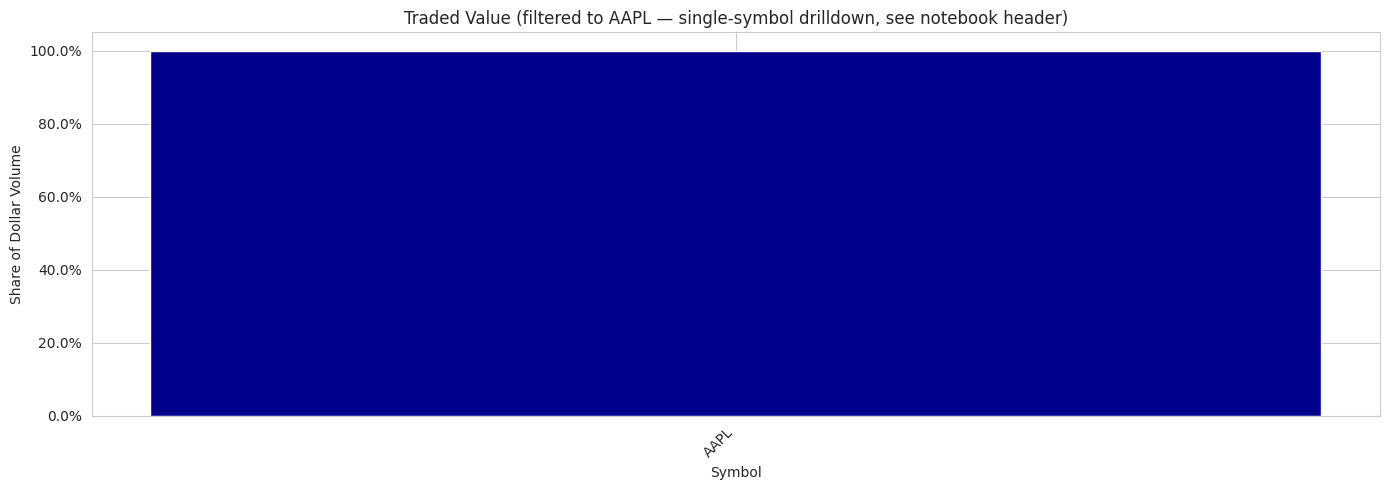


Single-symbol drilldown: AAPL accounts for 100.0% of traded dollar volume within the filtered slice.


In [26]:
if HAS_MESSAGE_DATA and orders_with_exec is not None:
    # Get executed orders with ticker info
    executed_with_ticker = orders_with_exec.filter(
        pl.col("executed").is_not_null() & pl.col("ticker").is_not_null()
    )

    if len(executed_with_ticker) > 0 and "value" in executed_with_ticker.columns:
        # Aggregate by ticker
        ticker_summary = (
            executed_with_ticker.group_by("ticker")
            .agg(
                [
                    pl.col("value").sum().alias("value"),
                    pl.col("shares").sum().alias("shares"),
                    pl.len().alias("trade_count"),
                ]
            )
            .sort("value", descending=True)
        )

        total_value = ticker_summary.select(pl.col("value").sum()).item()
        ticker_summary = ticker_summary.with_columns(
            (pl.col("value") / total_value).alias("value_share")
        )

        # Top 25 (or fewer if the drilldown was scoped to a single symbol). The
        # loader filters to a single stock via the SYMBOL parameter for tractable
        # memory, so ticker_summary will typically have one row when SYMBOL is set.
        # Branch on whether a symbol filter is active rather than on row count, so
        # the chart label stays honest if SYMBOL is later widened to a list.
        top_25 = ticker_summary.head(25)
        n_symbols = len(top_25)
        total_share = top_25.select(pl.col("value_share").sum()).item()
        symbol_filtered = SYMBOL is not None

        # Convert to pandas for plotting
        top_25_pd = top_25.to_pandas()

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.bar(range(len(top_25_pd)), top_25_pd["value_share"], color="darkblue")
        ax.set_xticks(range(len(top_25_pd)))
        ax.set_xticklabels(top_25_pd["ticker"], rotation=45, ha="right")
        if symbol_filtered:
            ax.set_title(
                f"Traded Value (filtered to SYMBOL={SYMBOL} — "
                f"single-symbol drilldown, see notebook header)"
            )
        else:
            ax.set_title(f"Top {n_symbols} Symbols by Traded Value ({total_share:.1%} of total)")
        ax.set_xlabel("Symbol")
        ax.set_ylabel("Share of Dollar Volume")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1%}"))
        plt.tight_layout()
        plt.show()

        if symbol_filtered:
            print(
                f"\nSingle-symbol drilldown: SYMBOL={SYMBOL} accounts "
                f"for {total_share:.1%} of traded dollar volume within the filtered slice."
            )
        else:
            print(
                f"\nTop {n_symbols} symbols account for {total_share:.1%} of traded dollar volume"
            )

## 8. Execution Characteristics (Enriched Data)

Using the enriched E/C messages (from notebook 01), we can analyze execution
characteristics at the order level: fill side, execution prices, and price improvement.

In [27]:
# Load enriched execution data if available
# IMPORTANT: Filter by stock_locate to avoid loading full-day data (memory issue)
ENRICHED_DIR = MESSAGE_DIR / "enriched"

if ENRICHED_DIR.exists():
    enriched_e = None
    enriched_c = None

    e_file = ENRICHED_DIR / "E.parquet"
    c_file = ENRICHED_DIR / "C.parquet"

    # Apply stock_locate filter to avoid OOM on full-day data
    if e_file.exists():
        lf = pl.scan_parquet(e_file)
        if "stock_locate" in lf.collect_schema().names():
            lf = lf.filter(pl.col("stock_locate") == STOCK_LOCATE)
        enriched_e = lf.collect()
        print(f"Loaded {len(enriched_e):,} enriched E messages for {SYMBOL}")

    if c_file.exists():
        lf = pl.scan_parquet(c_file)
        if "stock_locate" in lf.collect_schema().names():
            lf = lf.filter(pl.col("stock_locate") == STOCK_LOCATE)
        enriched_c = lf.collect()
        print(f"Loaded {len(enriched_c):,} enriched C messages for {SYMBOL}")
else:
    print(f"Enriched data not found at {ENRICHED_DIR}")
    print("Run notebook 01 enrichment step to generate this data.")
    enriched_e = None
    enriched_c = None

Loaded 55,168 enriched E messages for AAPL
Loaded 227 enriched C messages for AAPL


In [28]:
# Execution by side (Buy vs Sell)
if enriched_e is not None and "side" in enriched_e.columns:
    side_summary = (
        enriched_e.filter(pl.col("side").is_not_null())
        .group_by("side")
        .agg(
            pl.col("executed_shares").sum().alias("total_shares"),
            pl.len().alias("execution_count"),
        )
    )

    print("\n=== Execution Summary by Side (E messages) ===")
    print(side_summary)

    if len(side_summary) > 0:
        total_exec = side_summary.select(pl.col("execution_count").sum()).item()
        buy_rows = side_summary.filter(pl.col("side") == "B")
        sell_rows = side_summary.filter(pl.col("side") == "S")
        buy_count = buy_rows["execution_count"].item() if len(buy_rows) > 0 else 0
        sell_count = sell_rows["execution_count"].item() if len(sell_rows) > 0 else 0

        print(f"\nBuy executions:  {buy_count:>10,} ({buy_count / total_exec:.1%})")
        print(f"Sell executions: {sell_count:>10,} ({sell_count / total_exec:.1%})")
    else:
        print("  No executions with side information available.")


=== Execution Summary by Side (E messages) ===
shape: (2, 3)
┌──────┬──────────────┬─────────────────┐
│ side ┆ total_shares ┆ execution_count │
│ ---  ┆ ---          ┆ ---             │
│ str  ┆ u32          ┆ u32             │
╞══════╪══════════════╪═════════════════╡
│ S    ┆ 2013325      ┆ 27461           │
│ B    ┆ 1922280      ┆ 27120           │
└──────┴──────────────┴─────────────────┘

Buy executions:      27,120 (49.7%)
Sell executions:     27,461 (50.3%)


In [29]:
# Price improvement analysis (C messages only)
if enriched_c is not None and "price_improvement_raw" in enriched_c.columns:
    # Filter to valid price improvement data
    valid_pi = enriched_c.filter(
        pl.col("price_improvement_raw").is_not_null() & pl.col("side").is_not_null()
    )

    if len(valid_pi) > 0:
        print("\n=== Price Improvement Analysis (C messages) ===")
        print("Note: C messages are executions at a DIFFERENT price than the order's limit.")
        print("Typically for hidden/iceberg orders.")

        # Analyze by side
        # For buys: negative price_improvement_raw = better (paid less than limit)
        # For sells: positive price_improvement_raw = better (received more than limit)
        for side_label, side_code, better_sign in [
            ("Buy", "B", "negative"),
            ("Sell", "S", "positive"),
        ]:
            side_data = valid_pi.filter(pl.col("side") == side_code)
            if len(side_data) == 0:
                continue

            pi = side_data["price_improvement_raw"]
            mean_pi = pi.mean()
            median_pi = pi.median()

            # Convert from price units (4 decimals) to dollars
            mean_pi_dollars = mean_pi / 10000
            median_pi_dollars = median_pi / 10000

            # Count improved vs worse
            if side_code == "B":
                improved = side_data.filter(pl.col("price_improvement_raw") < 0).height
                worse = side_data.filter(pl.col("price_improvement_raw") > 0).height
            else:
                improved = side_data.filter(pl.col("price_improvement_raw") > 0).height
                worse = side_data.filter(pl.col("price_improvement_raw") < 0).height
            same = side_data.filter(pl.col("price_improvement_raw") == 0).height

            print(f"\n{side_label} Orders ({len(side_data):,} executions):")
            print(f"  Mean price diff:   ${mean_pi_dollars:>8.4f}")
            print(f"  Median price diff: ${median_pi_dollars:>8.4f}")
            print(f"  Better than limit: {improved:>8,} ({improved / len(side_data):.1%})")
            print(f"  At limit price:    {same:>8,} ({same / len(side_data):.1%})")
            print(f"  Worse than limit:  {worse:>8,} ({worse / len(side_data):.1%})")


=== Price Improvement Analysis (C messages) ===
Note: C messages are executions at a DIFFERENT price than the order's limit.
Typically for hidden/iceberg orders.

Buy Orders (130 executions):
  Mean price diff:   $  0.0100
  Median price diff: $  0.0100
  Better than limit:        0 (0.0%)
  At limit price:           0 (0.0%)
  Worse than limit:       130 (100.0%)

Sell Orders (96 executions):
  Mean price diff:   $ -0.0100
  Median price diff: $ -0.0100
  Better than limit:        0 (0.0%)
  At limit price:           0 (0.0%)
  Worse than limit:        96 (100.0%)


### Execution Characteristics Summary

The enriched execution data reveals:

1. **Side Balance**: Buy and sell executions are roughly balanced in count
   but may differ in volume (informed traders tend to be directional)

2. **Price Improvement (C messages)**: Most hidden order fills occur at
   or near the limit price, with small price improvements/disimprovements

3. **Order Attribution**: By joining executions back to their original orders,
   we can track the full order lifecycle and analyze execution quality

## Key Takeaways

### Order Lifecycle Statistics

| Metric | Typical Value | Implication |
|--------|---------------|-------------|
| **Cancellation Rate** | ~96% | Most visible liquidity is phantom |
| **Median Cancel Time** | <1 second | Quotes update continuously |
| **Execution Rate** | ~4% | Only a small fraction of orders trade |
| **Volume Concentration** | Top 25 dominate | Focus on liquid names |

### Implications for Trading

1. **Don't trust displayed liquidity**: Most of it will disappear before you can trade against it

2. **Speed matters**: Orders that execute do so quickly; stale orders are cancelled

3. **Market making is dynamic**: The ~96% cancellation rate reflects continuous quote updating

4. **Adverse selection**: Orders that *do* get filled may be picked off by informed traders

### Next Steps

- **Notebook 05**: `trading_activity_overview` - Message counts and volume concentration
- **Notebook 06**: `intraday_patterns` - U-shape in volume and volatility
- **Chapter 8**: Build predictive features from order flow data

---

**Reference**: Harris, L. (2003). *Trading and Exchanges: Market Microstructure for Practitioners*.
Oxford University Press.

---

## 5. Market-Wide Lifecycle Statistics

The single-stock analysis above characterizes AAPL order dynamics.
This section computes the same timing metrics across **all** ~186.6M orders
(A+F messages) to produce the market-wide statistics cited in Chapter 3.

In [30]:
# Market-wide time-to-cancellation and time-to-execution
# Load just (order_ref, timestamp) for memory efficiency — no symbol filter
if HAS_MESSAGE_DATA:
    import time as _time

    print("Loading market-wide order data (A+F, D, E messages)...")
    _t0 = _time.time()

    # All Add orders (A + F) — no symbol filter
    _adds_a = pl.scan_parquet(MESSAGE_DIR / "A" / "*.parquet").select(
        pl.col("order_reference_number").alias("order"),
        pl.col("timestamp").alias("submitted"),
    )
    _adds_f = pl.scan_parquet(MESSAGE_DIR / "F" / "*.parquet").select(
        pl.col("order_reference_number").alias("order"),
        pl.col("timestamp").alias("submitted"),
    )
    _all_adds = pl.concat([_adds_a, _adds_f])
    _n_total = _all_adds.select(pl.len()).collect().item()
    print(f"Total Add orders (A+F): {_n_total:,} ({_time.time() - _t0:.1f}s)")

    # --- Time to Cancellation ---
    print("\nComputing time-to-cancellation...")
    _t1 = _time.time()
    _all_deletes = (
        pl.scan_parquet(MESSAGE_DIR / "D" / "*.parquet")
        .select(
            pl.col("order_reference_number").alias("order"),
            pl.col("timestamp").alias("deleted"),
        )
        .group_by("order")
        .agg(pl.col("deleted").min())
    )
    _cancel_times = (
        _all_adds.join(_all_deletes, on="order", how="inner")
        .with_columns(
            (pl.col("deleted") - pl.col("submitted")).dt.total_nanoseconds().alias("cancel_ns")
        )
        .select("cancel_ns")
        .collect()
    )
    _ct = _cancel_times["cancel_ns"].cast(pl.Float64) / 1e9
    _n_cancelled = len(_cancel_times)
    print(f"Orders with delete events: {_n_cancelled:,} ({_time.time() - _t1:.1f}s)")

    _within_500ms = (_ct < 0.5).mean()
    _within_1s = (_ct < 1.0).mean()
    _within_10s = (_ct < 10.0).mean()
    _median_cancel = _ct.median()

    print(f"\nTime to Cancellation (market-wide, {_n_cancelled:,} orders):")
    print(f"  Within 500ms:    {_within_500ms:.1%}")
    print(f"  Within 1 second: {_within_1s:.1%}")
    print(f"  Within 10 seconds: {_within_10s:.1%}")
    print(f"  Median: {_median_cancel:.2f}s")
    del _cancel_times, _ct

    # --- Time to Execution ---
    print("\nComputing time-to-execution...")
    _t2 = _time.time()
    _all_execs = (
        pl.scan_parquet(MESSAGE_DIR / "E" / "*.parquet")
        .select(
            pl.col("order_reference_number").alias("order"),
            pl.col("timestamp").alias("executed"),
        )
        .group_by("order")
        .agg(pl.col("executed").min())
    )
    _exec_times = (
        _all_adds.join(_all_execs, on="order", how="inner")
        .with_columns(
            (pl.col("executed") - pl.col("submitted")).dt.total_nanoseconds().alias("exec_ns")
        )
        .select("exec_ns")
        .collect()
    )
    _et = _exec_times["exec_ns"].cast(pl.Float64) / 1e9
    _n_executed = len(_exec_times)
    print(f"Orders with execution events: {_n_executed:,} ({_time.time() - _t2:.1f}s)")

    _within_1ms = (_et < 0.001).mean()
    _median_exec = _et.median()
    _over_40min = (_et > 2400).mean()

    print(f"\nTime to Execution (market-wide, {_n_executed:,} orders):")
    print(f"  Within 1ms: {_within_1ms:.1%}")
    print(f"  Median: {_median_exec:.1f}s")
    print(f"  Over 40 minutes: {_over_40min:.1%}")
    del _exec_times, _et

    print(f"\nTotal runtime: {_time.time() - _t0:.1f}s")

Loading market-wide order data (A+F, D, E messages)...


Total Add orders (A+F): 186,610,705 (0.5s)

Computing time-to-cancellation...


Orders with delete events: 172,764,815 (77.6s)



Time to Cancellation (market-wide, 172,764,815 orders):
  Within 500ms:    41.4%
  Within 1 second: 50.2%
  Within 10 seconds: 80.2%
  Median: 1.00s

Computing time-to-execution...


Orders with execution events: 6,258,508 (3.0s)

Time to Execution (market-wide, 6,258,508 orders):
  Within 1ms: 10.5%
  Median: 6.1s
  Over 40 minutes: 1.0%

Total runtime: 85.7s


**Market-wide findings** confirm the values cited in the chapter:
- 41% of cancellations within 500ms, 50% within 1 second, 80% within 10 seconds
- Median cancellation time: ~1 second
- 10% of executions within 1ms, median 6 seconds, 1% wait over 40 minutes

These patterns reflect algorithmic market making: rapid quoting and cancellation
(sub-second) with relatively slower execution for resting orders that do fill.

---

## Reference

Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018).
*Trades, Quotes and Prices: Financial Markets Under the Microscope*.
Cambridge University Press.
[https://doi.org/10.1017/9781009028943](https://doi.org/10.1017/9781009028943)